In [2]:
# Cell 1 - Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
# Cell 2 - Load California Housing Dataset

df = pd.read_csv(r"C:\Users\HP 15\Downloads\archive (12)\housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# Cell 3 - Check Dataset Information

print(df.shape)

df.info()

(20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
# Cell 4 - Check Missing Values

df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
# Cell 5 - Remove Missing Values

df = df.dropna()

df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [7]:
# Cell 6 - Convert Categorical Data into Numerical

df = pd.get_dummies(df, columns=['ocean_proximity'])

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [8]:
# Cell 7 - Separate Input and Output

X = df.drop('median_house_value', axis=1)

y = df['median_house_value']

In [9]:
# Cell 8 - Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
# Cell 9 - Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16346, 13)
(4087, 13)


In [11]:
# Cell 10 - Build ANN Model

model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1))

c:\Users\HP 15\Desktop\tensorflow_vscode\myenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Cell 11 - Compile the Model

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Cell 12 - Train the ANN Model

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 55700709376.0000 - mae: 206214.0156 - val_loss: 55859474432.0000 - val_mae: 206222.3594
Epoch 2/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 53798715392.0000 - mae: 202258.3125 - val_loss: 52154142720.0000 - val_mae: 198521.5938
Epoch 3/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 47759122432.0000 - mae: 189240.4688 - val_loss: 43937075200.0000 - val_mae: 180164.2812
Epoch 4/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 37750038528.0000 - mae: 165034.5938 - val_loss: 32846657536.0000 - val_mae: 151613.4688
Epoch 5/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 26574594048.0000 - mae: 132998.8906 - val_loss: 22456446976.0000 - val_mae: 119283.9609
Epoch 6/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17752250368.0000 - mae: 103208.6172 - val_loss: 15623259136.0000 - val_mae: 95538.2031
Epoch 7/50
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12776849408.0000 - mae: 86061.0000 - val_loss: 123115

In [14]:
# Cell 13 - Predict the Values

y_pred = model.predict(X_test)

print(y_pred[:5])

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[193716.88]
 [140237.55]
 [204662.6 ]
 [183057.6 ]
 [167339.38]]


In [15]:
# Cell 14 - Evaluate Model Performance

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE :", rmse)
print("MAE :", mae)
print("R2 Score :", r2)

MSE : 4690558646.620673
RMSE : 68487.65324217697
MAE : 48990.51886108787
R2 Score : 0.6570020740489265


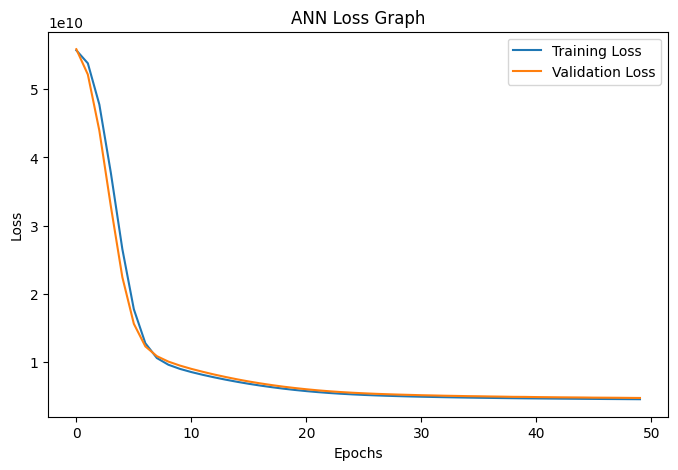

In [16]:
# Cell 15 - Plot Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("ANN Loss Graph")

plt.legend()

plt.show()

In [17]:
# Cell 16 - Compare Actual vs Predicted Values

comparison = pd.DataFrame({
    'Actual Value': y_test.values,
    'Predicted Value': y_pred.flatten()
})

comparison.head(20)

,Actual Value,Predicted Value
0,245800.0,193716.875000
1,137900.0,140237.546875
2,218200.0,204662.593750
3,220800.0,183057.593750
4,170500.0,167339.375000
5,75000.0,84020.078125
6,269400.0,279223.031250
7,228900.0,259821.578125
8,500001.0,365898.718750
9,80800.0,91664.843750


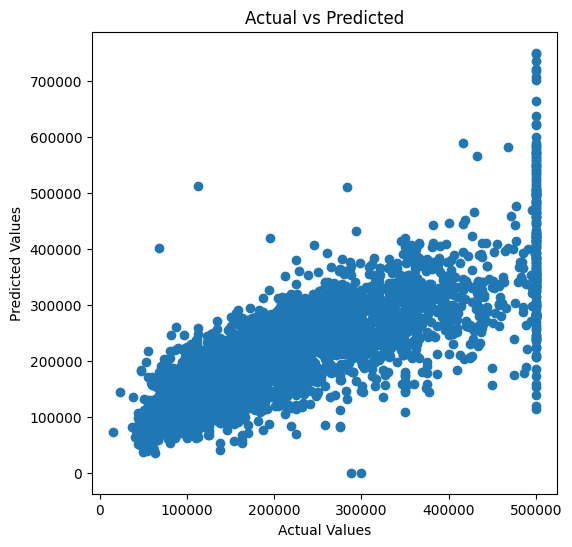

In [18]:
# Cell 17 - Scatter Plot

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()